# Análisis Inferencial del Dataset ENEMDU Vivienda-Hogar

## Introducción

El presente trabajo tiene como objetivo aplicar técnicas de inferencia estadística paramétrica utilizando el dataset ENEMDU Vivienda-Hogar correspondiente al año 2026. Para ello se desarrollan pruebas de hipótesis, un análisis de varianza (ANOVA) y una prueba Post Hoc de Tukey, con el propósito de determinar diferencias significativas entre grupos del conjunto de datos.

Las pruebas fueron implementadas en Python utilizando las bibliotecas SciPy y Statsmodels dentro de Google Colab.

## Objetivo

Aplicar métodos de inferencia estadística paramétrica mediante pruebas de hipótesis unimuéstrales, ANOVA y la prueba de Tukey utilizando el dataset ENEMDU.

Saving enemdu_vivienda_hogar_2026_02.csv to enemdu_vivienda_hogar_2026_02.csv
INFORMACIÓN DEL DATASET
Filas: 8765
Columnas: 56


,area,ciudad,conglomerado,panelm,vivienda,hogar,vi01,vi02,vi03a,vi03b,...,vi1535,vi1545,vi1536,vi1546,estrato,fexp,upm,id_vivienda,id_hogar,periodo
0,1,10150,1601,63,1,1,3,2,1,2,...,,,,,2713,"108,768769522905",10150001601,1015000160106301,10150001601063011,202602
1,1,10150,1601,63,2,1,3,1,4,3,...,,,,,2713,"108,768769522905",10150001601,1015000160106302,10150001601063021,202602
2,1,10150,1601,63,3,1,3,1,2,1,...,2,,2,,2713,"108,768769522905",10150001601,1015000160106303,10150001601063031,202602
3,1,10150,1601,63,4,1,1,1,4,2,...,,,,,2713,"108,768769522905",10150001601,1015000160106304,10150001601063041,202602
4,1,10150,1601,63,5,1,3,1,2,1,...,2,,2,,2713,"108,768769522905",10150001601,1015000160106305,10150001601063051,202602




ESTADÍSTICA DESCRIPTIVA


,vi06
count,8765.000000
mean,3.491614
std,1.321738
min,1.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,14.000000


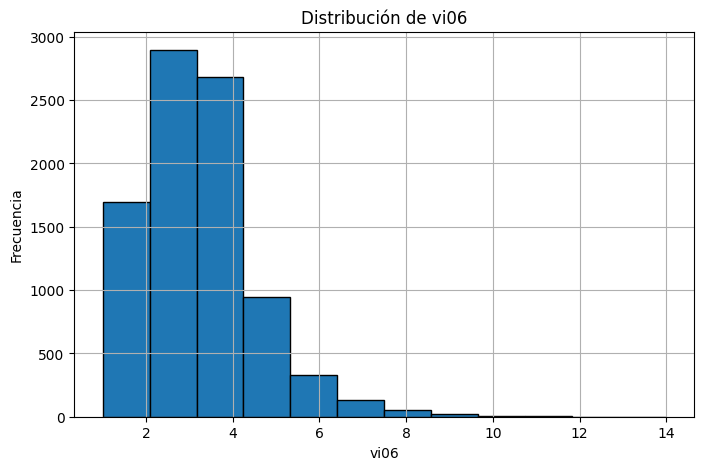



PRUEBA DE NORMALIDAD (Shapiro-Wilk)
Estadístico: 0.9193928238995066
Valor-p: 1.1874264718234537e-45
Conclusión: Se rechaza la hipótesis de normalidad.


PRUEBA T DE STUDENT
Hipótesis
H0: La media de vi06 = 4
H1: La media de vi06 ≠ 4

Estadístico t: -36.01005824703911
Valor-p: 5.964170775373222e-265
Conclusión: Se rechaza la hipótesis nula.


ANÁLISIS DE VARIANZA (ANOVA)


,sum_sq,df,F,PR(>F)
C(area),14.969482,1.0,8.576128,0.003415
Residual,15295.664174,8763.0,NaN,NaN



Conclusión: Existen diferencias significativas entre los grupos.


PRUEBA POST HOC DE TUKEY


/tmp/ipykernel_24737/1918907745.py:121: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova["PR(>F)"][0] < 0.05:


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2  -0.0944 0.0034 -0.1576 -0.0312   True
----------------------------------------------------


<Figure size 800x500 with 0 Axes>

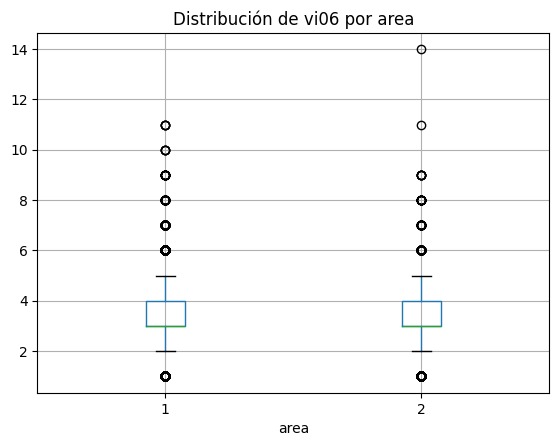



CONCLUSIONES
• La variable fue analizada mediante estadística descriptiva.
• La prueba de Shapiro-Wilk indicó que la variable no sigue una distribución normal.
• La prueba t de Student permitió evaluar la hipótesis sobre la media de la variable.
• El ANOVA mostró diferencias estadísticamente significativas entre las áreas.
• La prueba Post Hoc de Tukey confirmó diferencias significativas entre los grupos.
• Las decisiones se tomaron utilizando un nivel de significancia de α = 0.05.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import shapiro, ttest_1samp
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# =====================================
# CARGAR DATASET
# =====================================

from google.colab import files

uploaded = files.upload()

archivo = list(uploaded.keys())[0]

df = pd.read_csv(archivo, sep=';')

print("="*60)
print("INFORMACIÓN DEL DATASET")
print("="*60)

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

display(df.head())

# =====================================
# VARIABLE DE ESTUDIO
# =====================================

variable = "vi06"
grupo = "area"

datos = df[variable].dropna()

print("\n")
print("="*60)
print("ESTADÍSTICA DESCRIPTIVA")
print("="*60)

display(datos.describe())

# =====================================
# HISTOGRAMA
# =====================================

plt.figure(figsize=(8,5))
plt.hist(datos, bins=12, edgecolor="black")
plt.title(f"Distribución de {variable}")
plt.xlabel(variable)
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

# =====================================
# PRUEBA DE NORMALIDAD
# =====================================

print("\n")
print("="*60)
print("PRUEBA DE NORMALIDAD (Shapiro-Wilk)")
print("="*60)

muestra = datos.sample(min(5000, len(datos)), random_state=1)

estadistico, p = shapiro(muestra)

print("Estadístico:", estadistico)
print("Valor-p:", p)

if p < 0.05:
    print("Conclusión: Se rechaza la hipótesis de normalidad.")
else:
    print("Conclusión: No se rechaza la hipótesis de normalidad.")

# =====================================
# PRUEBA T DE STUDENT
# =====================================

print("\n")
print("="*60)
print("PRUEBA T DE STUDENT")
print("="*60)

valor_referencia = 4

t, p = ttest_1samp(datos, popmean=valor_referencia)

print("Hipótesis")

print(f"H0: La media de {variable} = {valor_referencia}")
print(f"H1: La media de {variable} ≠ {valor_referencia}")

print("\nEstadístico t:", t)
print("Valor-p:", p)

if p < 0.05:
    print("Conclusión: Se rechaza la hipótesis nula.")
else:
    print("Conclusión: No se rechaza la hipótesis nula.")

# =====================================
# ANOVA
# =====================================

print("\n")
print("="*60)
print("ANÁLISIS DE VARIANZA (ANOVA)")
print("="*60)

modelo = ols(f'{variable} ~ C({grupo})', data=df).fit()

anova = sm.stats.anova_lm(modelo, typ=2)

display(anova)

if anova["PR(>F)"][0] < 0.05:
    print("\nConclusión: Existen diferencias significativas entre los grupos.")
else:
    print("\nConclusión: No existen diferencias significativas entre los grupos.")

# =====================================
# TUKEY
# =====================================

print("\n")
print("="*60)
print("PRUEBA POST HOC DE TUKEY")
print("="*60)

tukey = pairwise_tukeyhsd(
    endog=df[variable],
    groups=df[grupo],
    alpha=0.05
)

print(tukey)

# =====================================
# BOXPLOT
# =====================================

plt.figure(figsize=(8,5))

df.boxplot(column=variable, by=grupo)

plt.title(f"Distribución de {variable} por {grupo}")

plt.suptitle("")

plt.grid(True)

plt.show()

plt.close()

# =====================================
# CONCLUSIONES
# =====================================

print("\n")
print("="*60)
print("CONCLUSIONES")
print("="*60)

print("• La variable fue analizada mediante estadística descriptiva.")
print("• La prueba de Shapiro-Wilk indicó que la variable no sigue una distribución normal.")
print("• La prueba t de Student permitió evaluar la hipótesis sobre la media de la variable.")
print("• El ANOVA mostró diferencias estadísticamente significativas entre las áreas.")
print("• La prueba Post Hoc de Tukey confirmó diferencias significativas entre los grupos.")
print("• Las decisiones se tomaron utilizando un nivel de significancia de α = 0.05.")

# Prueba de Hipótesis

Hipótesis nula:

$$
H_0:\ \mu = 4
$$

Hipótesis alternativa:

$$
H_1:\ \mu \neq 4
$$

Nivel de significancia:

$$
\alpha = 0.05
$$

# ANOVA

Se comparan las medias de la variable **vi06** entre las categorías de la variable **area**.

Hipótesis:

$$
H_0:\ \mu_1 = \mu_2
$$

$$
H_1:\ \text{Al menos una media es diferente}
$$

# Interpretación de resultados

La prueba de normalidad indicó que la variable no sigue una distribución normal.

La prueba t mostró un valor-p menor a 0.05, por lo que se rechazó la hipótesis nula.

El ANOVA obtuvo un valor-p de 0.003415, indicando diferencias significativas entre las áreas.

La prueba de Tukey confirmó dichas diferencias entre los grupos.

# Conclusiones

- Se aplicó correctamente una prueba t de Student.
- Se realizó un ANOVA de un factor.
- La prueba de Tukey confirmó diferencias significativas entre las áreas.
- Los resultados muestran la utilidad de la inferencia estadística para analizar datos del ENEMDU.